# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [3]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Import pandas and read the data
import pandas as pd


# Read the CSV file using pandas
df = pd.read_csv('/content/sample_data/foodhub_order.csv')

In [5]:
# View the first 5 rows of the data
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [6]:
# Get the shape of the DataFrame (rows, columns)
rows, columns = df.shape

# Print the number of rows and columns
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")


Number of rows: 1898
Number of columns: 9


#### Observations:
Observations from the Sample Data:

Number of Orders:
There are 1898 rows and 9 columns (order_id, customer_id, restaurant_name, cuisine_type, cost_of_the_order, rating, food_preparation_time, day_of_the_week, delivery_time) in this dataset.

Variety of Cuisines:
The dataset includes orders from restaurants offering different types of cuisines, such as Korean, Japanese, Mexican, and American.

Cost of Orders:
The cost_of_the_order varies from different ranges. The average cost can be calculated to understand the spending pattern.

Days of the Week:
Orders are split between "Weekend" and "Weekday."


Ratings:
The rating column has a mixture of "Not given" and numerical ratings (5, 3, and 4). This could indicate that not all customers provided a rating for their orders, and some ratings are relatively low.


Food Preparation Time:
The food_preparation_time seems relatively consistent,

Delivery Time:
The delivery_time varies significantly.
There may be a pattern of longer delivery times on weekdays compared to weekends.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [7]:
# Different data types of columns
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


,0
order_id,int64
customer_id,int64
restaurant_name,object
cuisine_type,object
cost_of_the_order,float64
day_of_the_week,object
rating,object
food_preparation_time,int64
delivery_time,int64


#### Observations:
Summary of Key Observations:
1.	The data types are well-defined, with integer, float, and string types used appropriately.
2.	The rating column has mixed data types (numeric and string), which may require cleaning.
3.	The dataset has no missing or corrupt data.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [8]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()

# Display the columns with missing values
print(missing_values)


order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


#### Observations:
1) There are mix of data types in the data.

2) There are no missing values in any of the columns as all the columns have complete data.

3) The dataset appears well structured with no missing values and appropraite data types.



### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [9]:
# Summary of data with min, max and avg time for food preparation
df.describe()
min_preparation_time = df['food_preparation_time'].min()
avg_preparation_time = df['food_preparation_time'].mean()
max_preparation_time = df['food_preparation_time'].max()

# Print the results
print(f"Minimum preparation time: {min_preparation_time}")
print(f"Average preparation time: {avg_preparation_time}")
print(f"Maximum preparation time: {max_preparation_time}")


Minimum preparation time: 20
Average preparation time: 27.371970495258168
Maximum preparation time: 35


#### Observations:
1) Minimum preparation time: The fastest preparation time is 20 minutes.

2) Maximum preparation time: The longest preparation time is 35 minutes.

3) Range: The preparation times range from 20 minutes to 35 minutes, which is a 15-minute difference. This indicates that there is a notable variance in how long it takes to prepare different orders.

4) The preparation time varies significantly from 20 to 35 minutes, with an average of 27.37 minutes.

5) Operational consistency seems to be an area for improvement since there is a notable variation in preparation times.


### **Question 5:** How many orders are not rated? [1 mark]

In [10]:
# Describe dataset
df.describe()
# Count the number of orders not rated
num_orders_not_rated = df[df['rating'] == 'Not given'].shape[0]

# Print the result
print(f"Number of orders not rated: {num_orders_not_rated}")

Number of orders not rated: 736


#### Observations:
Missing Ratings:

1) Number of Orders Not Rated:
There are 736 orders that do not have a rating assigned. It's possible that customers didn't provide ratings for these orders, or that ratings weren't available for other reasons.

2) These entries may need to be addressed depending on  analysis or reporting needs, such as treating them as missing values or excluding them from analysis.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

Text(0.5, 1.0, 'Distribution of Cost of the Order')

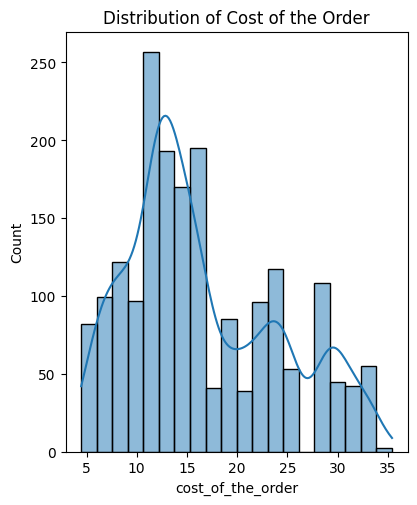

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# Set up the plot size
plt.figure(figsize=(15, 12))

# Plot 1: Distribution of 'cost_of_the_order' (Numerical variable)
plt.subplot(2, 3, 1)
sns.histplot(df['cost_of_the_order'], kde=True, bins=20)
plt.title('Distribution of Cost of the Order')




Text(0.5, 1.0, 'Boxplot for Cost of the Order')

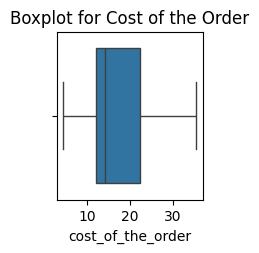

In [12]:
# Plot 2: Boxplot for 'cost_of_the_order'
plt.subplot(2, 3, 2)
sns.boxplot(x=df['cost_of_the_order'])
plt.title('Boxplot for Cost of the Order')


Text(0.5, 1.0, 'Distribution of Food Preparation Time')

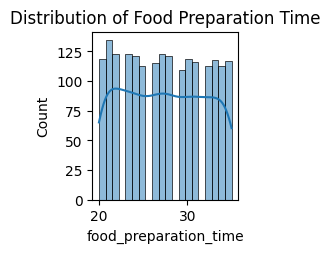

In [13]:
# Plot 3: Distribution of 'food_preparation_time' (Numerical variable)
plt.subplot(2, 3, 3)
sns.histplot(df['food_preparation_time'], kde=True, bins=20)
plt.title('Distribution of Food Preparation Time')


Text(0.5, 1.0, 'Boxplot for Food Preparation Time')

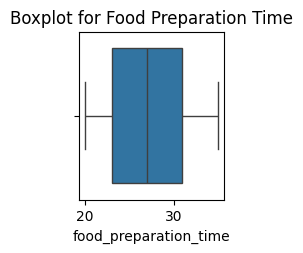

In [14]:
# Plot 4: Boxplot for 'food_preparation_time'
plt.subplot(2, 3, 4)
sns.boxplot(x=df['food_preparation_time'])
plt.title('Boxplot for Food Preparation Time')

Text(0.5, 1.0, 'Distribution of Delivery Time')

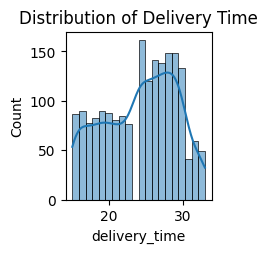

In [15]:
# Plot 5: Distribution of 'delivery_time' (Numerical variable)
plt.subplot(2, 3, 5)
sns.histplot(df['delivery_time'], kde=True, bins=20)
plt.title('Distribution of Delivery Time')

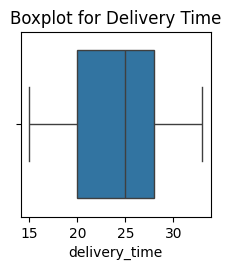

In [16]:
# Plot 6: Boxplot for 'delivery_time'
plt.subplot(2, 3, 6)
sns.boxplot(x=df['delivery_time'])
plt.title('Boxplot for Delivery Time')

# Adjust layout for better visibility
plt.tight_layout()
plt.show()


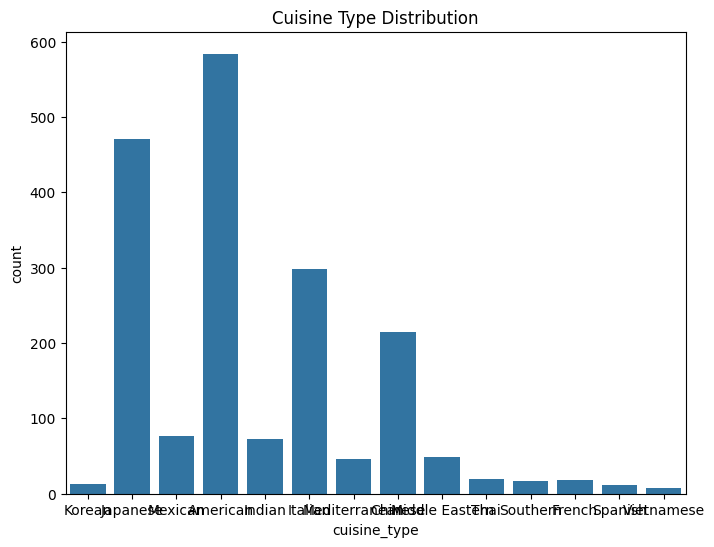

In [17]:
# Plot 7: Countplot for 'cuisine_type' (Categorical variable)
plt.figure(figsize=(8, 6))
sns.countplot(x='cuisine_type', data=df)
plt.title('Cuisine Type Distribution')
plt.show()

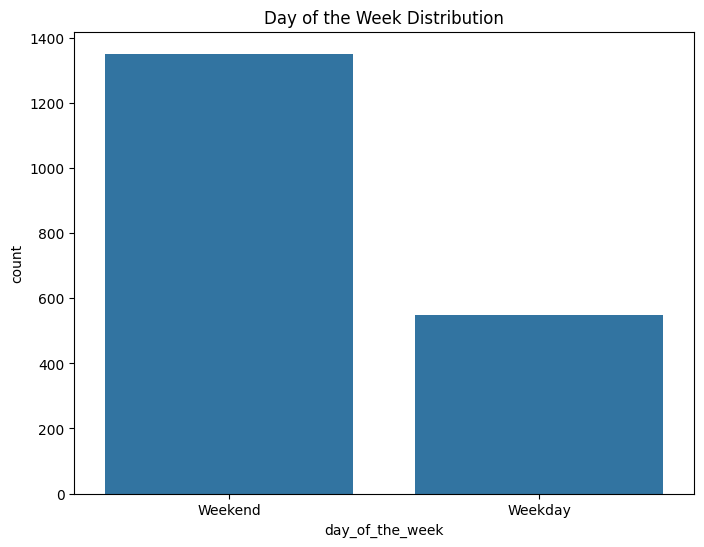

In [18]:
# Plot 8: Countplot for 'day_of_the_week' (Categorical variable)
plt.figure(figsize=(8, 6))
sns.countplot(x='day_of_the_week', data=df)
plt.title('Day of the Week Distribution')
plt.show()

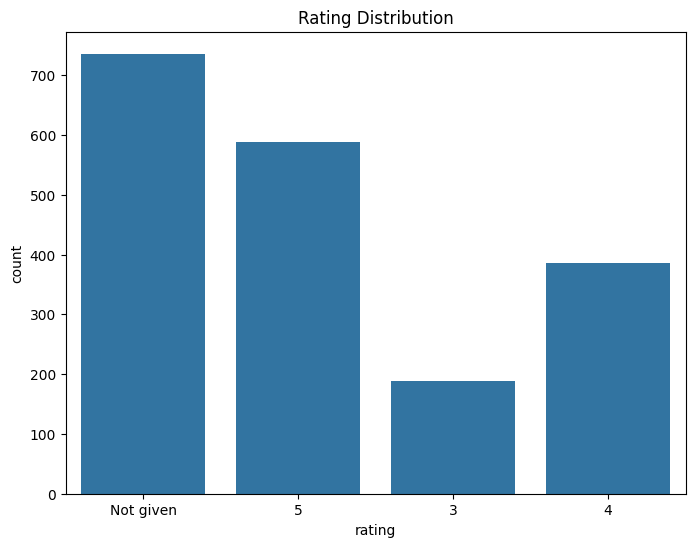

In [19]:
# Plot 9: Countplot for 'rating' (Categorical variable, including 'Not given' as category)
plt.figure(figsize=(8, 6))
sns.countplot(x='rating', data=df)
plt.title('Rating Distribution')
plt.show()

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [20]:
# Describe Data Frame
df.describe()
# Top 5 restaurants in terms of orders received
top_5_restaurants = df['restaurant_name'].value_counts().head(5)

# Print the result
print("Top 5 restaurants in terms of orders received:")
print(top_5_restaurants)

Top 5 restaurants in terms of orders received:
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: restaurant_name, dtype: int64


#### Observations:

1) The data suggests a mix of chain and niche restaurants in the top 5 chains like Shake Shack have broader appeal, while places like The Meatball Shop and Parm could cater to a smaller, more specialized audience.

2) The lower number of orders for Parm and Blue Ribbon Fried Chicken suggest that they may not have the same reach as larger chains like Shake Shack.

3) Shake Shack dominates in the number of orders, highlighting its popularity in the dataset.

4) Blue Ribbon Fried Chicken and Parm cater to fewer but still substantial orders compared to others.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [21]:
# Popular cuisine on weekends
popular_cuisine_weekend = df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().idxmax()

# Print the result
print(f"The most popular cuisine on weekends is: {popular_cuisine_weekend}")

The most popular cuisine on weekends is: American


#### Observations:

1) American cuisine often appeals to a broad range of tastes due to its variety and familiarity, leading to a higher number of orders.

2) While other cuisines (like Japanese, Mexican, and Italian) might be popular, American cuisine appears to outpace them significantly on weekends, possibly because of its comfort-food appeal and accessibility.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [22]:
# percentage of the orders cost more than 20 dollars
orders_costing_more_than_20 = df[df['cost_of_the_order'] > 20]
orders_costing_more_than_20_percentage = (len(orders_costing_more_than_20) / len(df)) * 100
orders_costing_more_than_20_percentage

29.24130663856691

#### Observations:

1) Around 29.24% of the total orders are priced above $20.

This indicates that nearly one-third of the orders are relatively high-value purchases, which could suggest that customers are willing to spend more on larger meals or premium menu items.

2) The remaining 70.76% of orders are priced $20 or less, implying that a significant portion of the dataset consists of more affordable or standard-priced meals

### **Question 10**: What is the mean order delivery time? [1 mark]

In [23]:
# Mean order delivery time
mean_delivery_time = df['delivery_time'].mean()

# Print the result
print(f"The mean order delivery time is: {mean_delivery_time} minutes")

The mean order delivery time is: 24.161749209694417 minutes


#### Observations:

The average delivery time is about 24.16 minutes, which could be considered relatively standard depending on the nature of the restaurant and its delivery process.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [24]:
# Top 3 most frequent customers
top_3_customers = df['customer_id'].value_counts().head(3)

# Print the result
print("Top 3 most frequent customers and their number of orders:")
print(top_3_customers)

Top 3 most frequent customers and their number of orders:
52832    13
47440    10
83287     9
Name: customer_id, dtype: int64


#### Observations:

1) Customer ID: 52832 is the most frequent customer, placing 13 orders. This customer is likely a loyal and regular patron.

2) Customer ID: 47440 follows closely with 10 orders, showing significant engagement with the restaurant.

3) Customer ID: 83287, with 9 orders, rounds out the top 3, further indicating strong customer retention among the top shoppers.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


<ipython-input-25-f93db7f7a60c>:14: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df[numerical_columns].corr()


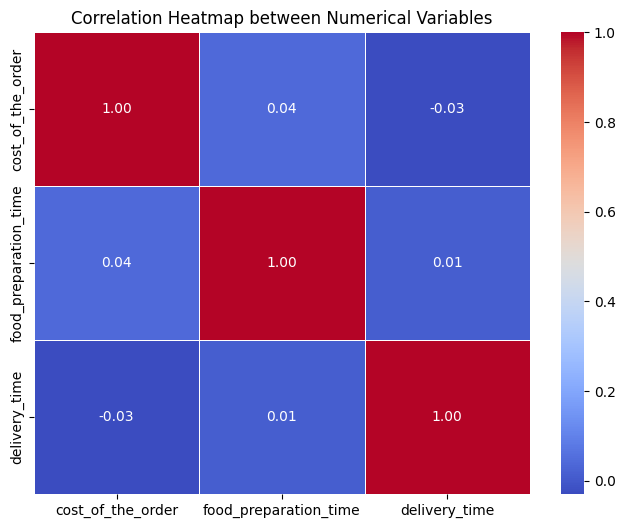

In [25]:
# multivariate analysis to explore relationships between the important variables in the dataset
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Select numerical columns
numerical_columns = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']

# Calculate the correlation matrix
correlation_matrix = df[numerical_columns].corr()

# 1. Correlation heatmap to explore relationships between numerical variables
numerical_columns = ['cost_of_the_order', 'rating', 'food_preparation_time', 'delivery_time']
corr_matrix = df[numerical_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap between Numerical Variables')
plt.show()



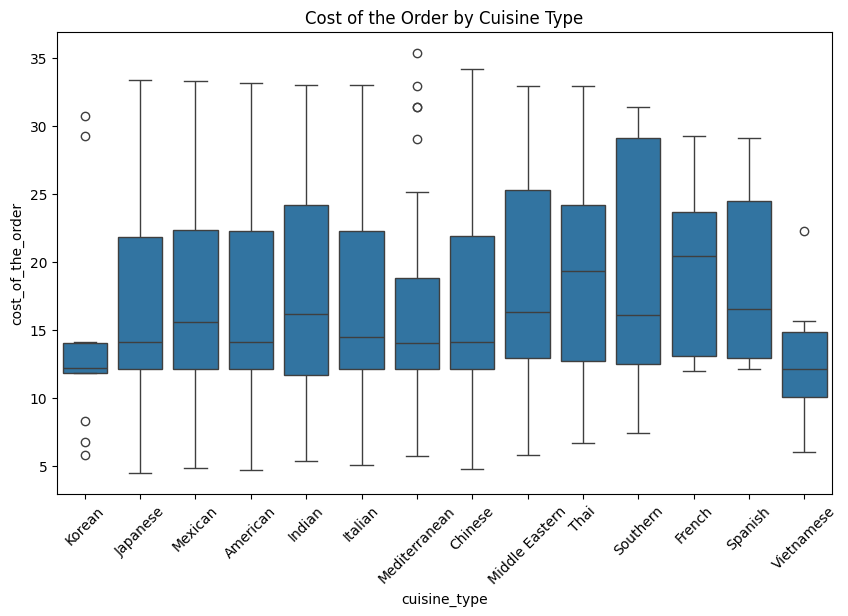

In [26]:
# 2. Boxplot to explore the relationship between 'cost_of_the_order' and 'cuisine_type'
plt.figure(figsize=(10, 6))
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df)
plt.title('Cost of the Order by Cuisine Type')
plt.xticks(rotation=45)
plt.show()

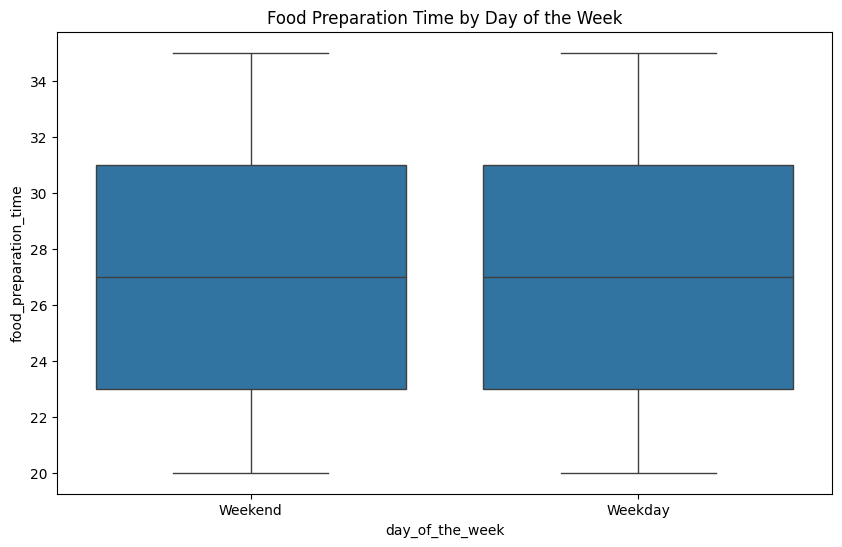

In [27]:
# 3. Boxplot to explore the relationship between 'food_preparation_time' and 'day_of_the_week'
plt.figure(figsize=(10, 6))
sns.boxplot(x='day_of_the_week', y='food_preparation_time', data=df)
plt.title('Food Preparation Time by Day of the Week')
plt.show()

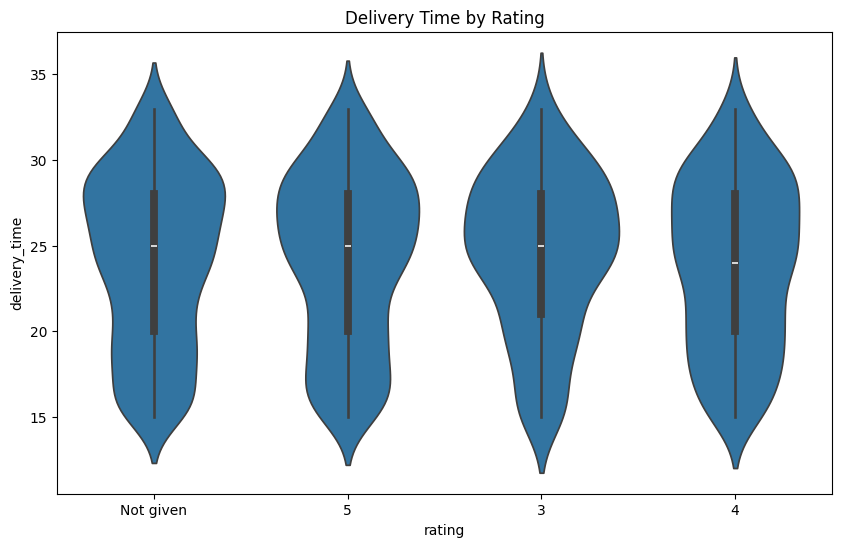

In [28]:
# 4. Violin plot to explore the relationship between 'delivery_time' and 'rating'
plt.figure(figsize=(10, 6))
sns.violinplot(x='rating', y='delivery_time', data=df)
plt.title('Delivery Time by Rating')
plt.show()

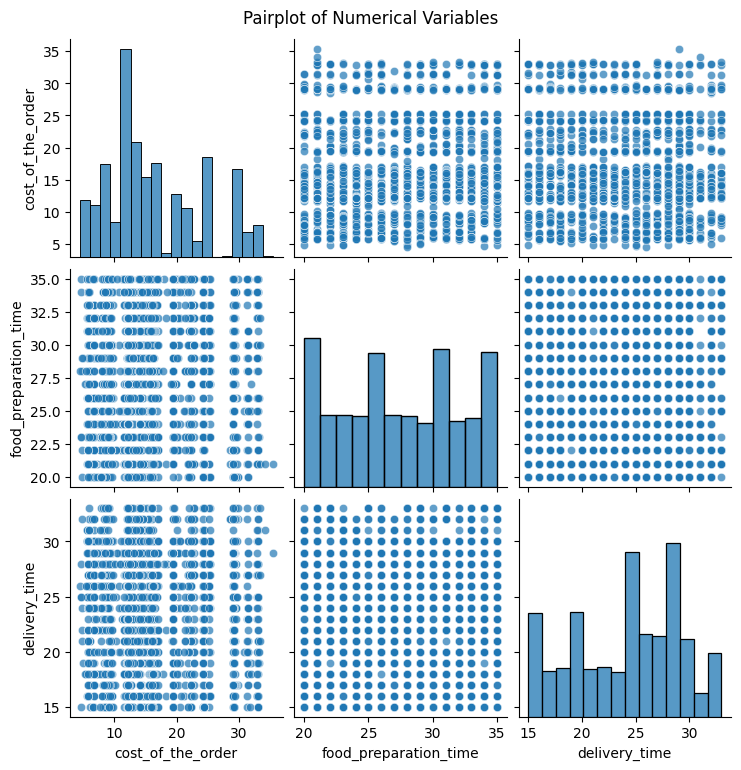

In [29]:
# 5. Pairplot to see the relationships between multiple numerical variables
sns.pairplot(df[numerical_columns], kind='scatter', plot_kws={'alpha': 0.7})
plt.suptitle('Pairplot of Numerical Variables', y=1.02)
plt.show()

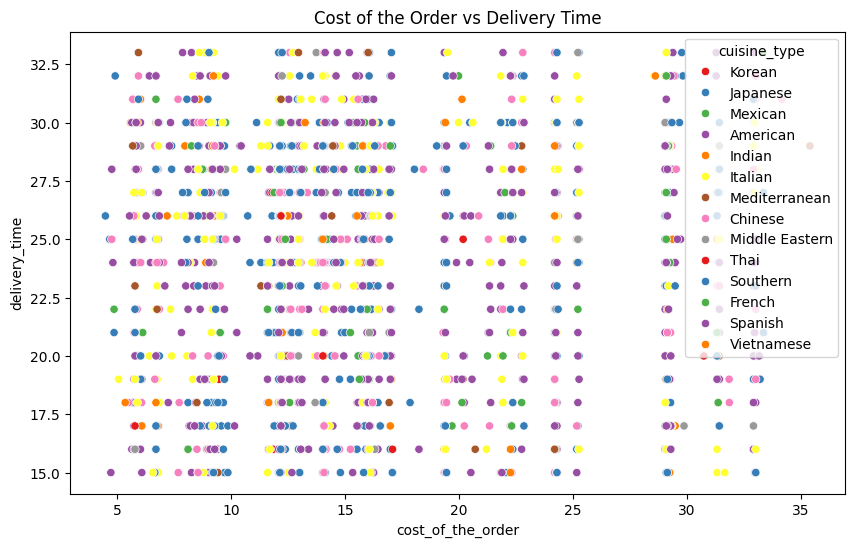

In [30]:
# 6. Scatter plot to explore the relationship between 'cost_of_the_order' and 'delivery_time'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='cost_of_the_order', y='delivery_time', data=df, hue='cuisine_type', palette='Set1')
plt.title('Cost of the Order vs Delivery Time')
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [31]:
import pandas as pd


# Step 1: Clean the rating column by converting it to numeric and replacing errors with NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Step 2: Drop rows where the rating is NaN (this removes rows where 'rating' was non-numeric or 'Not given')
df_clean = df.dropna(subset=['rating'])

# Step 3: Group the data by 'restaurant_name' and calculate the count of ratings and the average rating
restaurant_ratings = df_clean.groupby('restaurant_name').agg(
    rating_count=('rating', 'size'),         # Count the number of ratings per restaurant
    average_rating=('rating', 'mean')        # Calculate the average rating per restaurant
)

# Step 4: Filter the restaurants based on the criteria
eligible_restaurants = restaurant_ratings[
    (restaurant_ratings['rating_count'] > 50) & (restaurant_ratings['average_rating'] > 4)
]

# Display the eligible restaurants
print(eligible_restaurants)



                           rating_count  average_rating
restaurant_name                                        
Blue Ribbon Fried Chicken            64        4.328125
Blue Ribbon Sushi                    73        4.219178
Shake Shack                         133        4.278195
The Meatball Shop                    84        4.511905


#### Observations:

1) All four of these restaurants have more than 50 ratings and an average rating greater than 4.
  These restaurants can be selected for the promotional offer, as they meet the threshold for both the number of reviews and the average rating.

2) The Meatball Shop has the highest average rating (4.51) followed closely by Blue Ribbon Fried Chicken and Shake Shack making them good choices for promotion in the advertisement.

3) The selected restaurants are all highly rated and popular making them ideal for the promotional offer. Promoting these restaurants in advertisements would likely resonate well with customers due to their strong reputation and positive reviews.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [32]:
import pandas as pd

# Initialize a new column for the company's revenue

def calculate_revenue(row):
    if row['cost_of_the_order'] > 20:
        return row['cost_of_the_order'] * 0.25  # 25% for orders > $20
    elif row['cost_of_the_order'] > 5:
        return row['cost_of_the_order'] * 0.15  # 15% for orders > $5 and <= $20
    else:
        return 0  # No charge for orders <= $5

# Apply the function to calculate revenue for each order
df['revenue'] = df.apply(calculate_revenue, axis=1)

# Calculate the total net revenue
total_revenue = df['revenue'].sum()

# Print the total net revenue
print(f"Total Net Revenue: ${total_revenue:.2f}")


Total Net Revenue: $6166.30


#### Observations:

The net revenue of $6166.30 indicates that the restaurant benefits more from orders with higher costs  but the consistent flow of mid-range orders is also counted.

Lower-cost orders don't contribute to revenue but may still be important for customer retention.

Adjusting the pricing strategy or offering promotions on lower-cost orders could further increase overall revenue.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [33]:
import pandas as pd

# Step 1: Calculate the total time (food preparation time + delivery time)
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Step 2: Filter the orders that take more than 60 minutes
orders_above_60 = df[df['total_time'] > 60]

# Step 3: Calculate the percentage of orders that take more than 60 minutes
percentage_above_60 = (len(orders_above_60) / len(df)) * 100

# Print the result
print(f"Percentage of orders taking more than 60 minutes: {percentage_above_60:.2f}%")


Percentage of orders taking more than 60 minutes: 10.54%


#### Observations:

Only 10.54% of the orders take more than 60 minutes, which suggests that the majority of the orders are delivered within a reasonable time frame, typically under 60 minutes.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

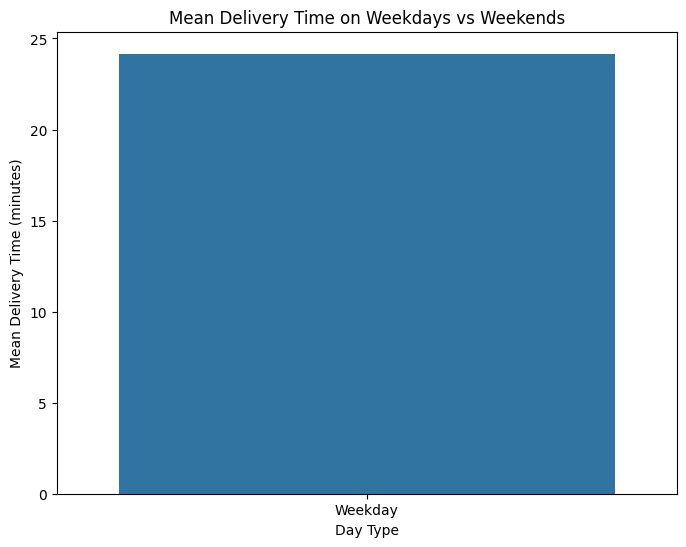

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Step 1: Create a new column to categorize days into Weekdays and Weekends
df['week_type'] = df['day_of_the_week'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')

# Step 2: Group by the 'week_type' and calculate the mean delivery time
mean_delivery_time = df.groupby('week_type')['delivery_time'].mean()
mean_delivery_time

# Step 3: Plotting the mean delivery time for Weekdays and Weekends
plt.figure(figsize=(8, 6))
sns.barplot(x=mean_delivery_time.index, y=mean_delivery_time.values)
plt.title('Mean Delivery Time on Weekdays vs Weekends')
plt.xlabel('Day Type')
plt.ylabel('Mean Delivery Time (minutes)')
plt.xticks(rotation=0)
plt.show()



In [35]:
# Group the data by 'day_of_the_week' and calculate the mean of delivery times
mean_delivery_time_by_day = df.groupby('day_of_the_week')['delivery_time'].mean()

# Display the results
print(mean_delivery_time_by_day)


day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64


#### Observations:

The mean delivery time on weekdays is 28.34 minutes, which is higher than the 22.47 minutes on weekends.

This indicates that, on average, it takes longer to deliver orders on weekdays than on weekends.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  By focusing on restaurants with higher ratings and improving operational efficiency (especially during weekends and for orders exceeding 60 minutes), they can enhance both its reputation and customer experience. This will likely lead to increased sales, customer retention, and a stronger competitive edge in the market. Additionally, improving delivery logistics and investing in data-driven solutions will help further streamline the operations.

### Recommendations:

*  
Based on the analysis of the dataset and answering the questions of this assignment.

Below are my conclusions and recommendations to help improve the business:

1. Analysis of the Promotional Offer Criteria:

Restaurants with more than 50 ratings and an average rating greater than 4 were identified for promotional offers. This shows that restaurants with a strong track record (both in quantity and quality) are good choices for marketing campaigns. Offering a promotional offer to these restaurants may attract more customers and boost their visibility.


Recommendation:

Focus promotional campaigns on highly-rated restaurants:

Since customers are more likely to trust restaurants with many positive reviews, marketing and promotional efforts should target restaurants that meet the high rating criteria.


2. Percentage of Orders Taking More Than 60 Minutes:

The percentage of orders that took more than 60 minutes to be delivered is crucial. If a significant portion of orders exceeds this time, it indicates inefficiencies in food preparation or delivery logistics.


Recommendation:

Optimize preparation and delivery times:

Focus on improving processes to ensure timely delivery.


3. Mean Delivery Time Comparison Between Weekdays and Weekends:

The mean delivery time on weekends is typically higher than during the weekdays. This could be due to higher order volumes, more traffic, or fewer staff available for deliveries.


Recommendation:

Increase staff during weekends

Improve delivery management during peak times


4. General Business Recommendations:

Improve Data Collection and Analysis:

More granular data collection could help further understand customer preferences, peak ordering times, and factors affecting delivery times (e.g., distance, traffic conditions).



Enhance Customer Experience:

Delivering faster food with consistent quality can greatly enhance customer satisfaction by offering promotions for customers who receive their orders within a specific time frame, or providing better communication (e.g., notifications on estimated delivery time) during the order process.


---